# Task 002 - Data Preparation

## CRISP-DM Phase 3

---

# مقدمه

در تسک قبلی شما مرحله **Data Understanding** را روی دیتاست بیماری قلبی انجام دادید.

در پایان آن مرحله باید به درک مناسبی از موارد زیر رسیده باشید:

* ساختار داده
* کیفیت داده
* ویژگی‌های مهم
* ارتباط ویژگی‌ها با متغیر هدف
* مشکلات موجود در داده
* مناسب بودن داده برای مدل‌سازی

اکنون وارد مرحله سوم فرآیند CRISP-DM یعنی **Data Preparation** می‌شویم.

---

# یادآوری چالش کسب‌وکار

شما به عنوان تحلیلگر داده در یک مرکز درمانی قلب و عروق فعالیت می‌کنید.

هدف کسب‌وکار:

تشخیص احتمال ابتلا به بیماری قلبی بر اساس ویژگی‌های بیماران.

متغیر هدف:

```python
target
```

* 0 → Healthy
* 1 → Heart Disease

---

# نوع مسئله داده‌کاوی

با توجه به تحلیل مرحله قبل:

متغیر هدف مشخص است و دو کلاس دارد.

بنابراین مسئله اصلی:

## Supervised Learning

و به طور دقیق‌تر:

## Binary Classification

---

# الگوریتم‌های احتمالی آینده

در مراحل بعدی ممکن است از الگوریتم‌های زیر استفاده شود:

* Logistic Regression
* Decision Tree
* Random Forest
* KNN
* SVM
* Naive Bayes

بنابراین باید داده را به شکلی آماده کنیم که برای این الگوریتم‌ها مناسب باشد.

---

# هدف این تسک

ایجاد یک دیتاست نهایی و آماده برای مرحله Modeling

---

# خروجی نهایی مورد انتظار

در پایان این تسک باید فایل زیر را ایجاد کنید:

```python
heart_prepared.csv
```

این فایل باید:

* تمیز باشد
* ویژگی‌های انتخاب شده را داشته باشد
* ویژگی‌های جدید مورد نیاز را داشته باشد
* فرمت مناسبی داشته باشد
* داده‌های عددی مقیاس‌بندی شده باشند
* برای مدل‌سازی آماده باشد

---

# قوانین

- استفاده از Scikit-Learn ممنوع
- استفاده از AutoML ممنوع


فقط از موارد زیر استفاده شود

- NumPy
- Pandas
- Matplotlib
- Seaborn

---

In [244]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [245]:
df = pd.read_csv("heart.csv")

In [246]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)

# بخش اول

# Data Selection

---

## سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

---

In [2]:
corr_with_target = df.corr(numeric_only=True)["target"].sort_values(ascending=False)
print(corr_with_target)

top_features = corr_with_target.drop("target").abs().sort_values(ascending=False)
print("\nmost important features (absolute values):")
print(top_features)

target      1.000000
cp          0.433798
thalach     0.421741
slope       0.345877
restecg     0.137230
fbs        -0.028046
chol       -0.085239
trestbps   -0.144931
age        -0.225439
sex        -0.280937
thal       -0.344029
ca         -0.391724
oldpeak    -0.430696
exang      -0.436757
Name: target, dtype: float64

most important features (absolute values):
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


به ترتیب 

exang

cp

oldpeak

thalach

ca

## سوال 2

یک جدول تهیه کنید:

---



| Feature | Business Importance | Data Importance(corr) | analysis |
| ------- | ------------------- | --------------- | -------- |
| cp | Very high — Chest pain type is one of the most direct clinical indicators |	High (0.434) |Consistent — Clinical and statistical importance agree|
| thalach | High — Maximum heart rate achieved during exercise | High (0.422) | Consistent |
| oldpeak | High — ST depression on ECG, a strong diagnostic indicator | High (0.431) | Consistent |
| exang	| High — Exercise-induced angina | High (0.437) | Consistent |
| ca | High — Number of major vessels colored by fluoroscopy | High (0.392)	| Consistent |
| thal | High — Thallium stress test result	| Moderate (0.344) | Fairly consistent |
| chol | High — Cholesterol is a classic medical risk factor | Low (0.085) | Inconsistent — Clinically important, but shows weak correlation in this dataset |
| trestbps | High — Resting blood pressure | Low (0.145) | Partially inconsistent |
| fbs | Moderate — Fasting blood sugar | Very low (0.028) | Inconsistent — Medically important, but has little predictive value in this dataset | 
| age | High — Age is an important risk factor | Moderate (0.225) | Fairly consistent |


*included research*

## سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

---

In [248]:
k2 = []
k2_value = 0
lst = boolian + categorical
for index , col in enumerate(df[lst].columns):
    df_cross = pd.crosstab(df[col],df["target"])
    t_row = df_cross.sum(axis = 1).values
    t_col = df_cross.sum(axis = 0).values
    total = df_cross.sum().sum()
    for i in range(len(df_cross)):
        for j in range(len(df_cross.columns)):
            o = df_cross.iloc[i,j]
            e = (t_row[i] * t_col[j])/total
            x = ((o-e) ** 2)/e
            k2_value += x
    k2.append((col,x))
l = pd.Series(k2)
print(l)
# numerical.append("target")
# df[numerical].groupby("target").agg(["mean","std"])




0         (sex, 3.450835518334441)
1       (fbs, 0.09242524252425258)
2      (exang, 17.723379610688337)
3      (target, 62.85148514851485)
4         (cp, 0.9642781669471296)
5    (restecg, 0.6373087308730875)
6      (slope, 11.386783889656568)
7         (ca, 0.5991359135913589)
8       (thal, 20.018077192334616)
dtype: object


In [249]:
df.corr()["target"].sort_values()

exang      -0.436757
oldpeak    -0.430696
ca         -0.391724
thal       -0.344029
sex        -0.280937
age        -0.225439
trestbps   -0.144931
chol       -0.085239
fbs        -0.028046
restecg     0.137230
slope       0.345877
thalach     0.421741
cp          0.433798
target      1.000000
Name: target, dtype: float64

fbs: 0.028 correlation ba target. kamtarin meghdar dar kole dataset. in sotun taghriban hich etelaate tamayoz dahandeii beine afrade salem va bimar eraee nemide. hamchenin be dalile mahiate binary va skewness shadid, toziie besiar asymetric y dare.

chol: 0.085 correlation ba target. ba vojood inke az lahaze pezeshki amele mohemie, vali tooye in dataset rabete zaiifi dare ba target. toziie in sotun ham daraye skewness ziad va outlier ziade. 

restECG: 0.137 correlation ba target. in sotun faghat se meghdare 0, 1 va 2 dare va toziiesh besiar asymmetric e. aksare bimara meghdare 0 ya 1 daran. pas ghodrate tamayoz mahdoodi dare. 


## سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

نام:

```python
selected_df
```

---

In [4]:
selected_columns = ["age", "sex", "cp", "trestbps", "thalach", "slope", "exang", "oldpeak", "ca", "thal", "target"]

selected_df = df[selected_columns].copy()
selected_df.head()

,age,sex,cp,trestbps,thalach,slope,exang,oldpeak,ca,thal,target
0,63,1,3,145,150,0,0,2.3,0,1,1
1,37,1,2,130,187,0,0,3.5,0,2,1
2,41,0,1,130,172,2,0,1.4,0,2,1
3,56,1,1,120,178,2,0,0.8,0,2,1
4,57,0,0,120,163,2,1,0.6,0,2,1


ba tavajoh be soalate ghabl, sotun haye chol, fbs، restecg va slope az dataset hazf shodan.


## سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

---

In [251]:
print("before selection: ", df.shape[1])
print("after selection: ", selected_df.shape[1])
print("deleted cols: ", df.shape[1] - selected_df.shape[1])
print("percentage removed: ", (df.shape[1] - selected_df.shape[1]) / df.shape[1] * 100)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
Index(['age', 'sex', 'cp', 'trestbps', 'thalach', 'exang', 'oldpeak', 'slope',
       'thal', 'target'],
      dtype='str')


# بخش دوم

# Data Cleaning

---

## سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

---

In [252]:
for index in df.columns:
    print(f"{index} -> {df[index].isna().sum()}")

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0


## سوال 7

برای هر ستون مشخص کنید:

* تعداد Null
* درصد Null

---

In [253]:
null_count = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

print(null_count, null_percent)

age -> 0
sex -> 0
cp -> 0
trestbps -> 0
chol -> 0
fbs -> 0
restecg -> 0
thalach -> 0
exang -> 0
oldpeak -> 0
slope -> 0
ca -> 0
thal -> 0
target -> 0

age -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

sex -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

cp -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.0
restecg     0.0
thalach     0.0
exang       0.0
oldpeak     0.0
slope       0.0
ca          0.0
thal        0.0
target      0.0
dtype: float64%

trestbps -> age         0.0
sex         0.0
cp          0.0
trestbps    0.0
chol        0.0
fbs         0.

## سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

---

Mean/Median Imputation: baraye sotun hate numerical continious mesle trestbps & thalach, Median behtar az mean ast chon in sotun ha Outlier daran va agar mean begirim be samte outlier keshide mishe. 

Mode Imputation: baraye cp, thal va ca, ba por tekrar tarin maghadir por mishe chon fasele beine maghadire in sotun ha maanaye riazi nadaran.

Group-based Imputation: bejaye inke bar asase kole dataset missing value haro por konim, bar asase dade (record) haye moshabeh inkaro mikonim. aval dataset ro group bandi mikonim bar asase sotun haye dige, baad frequent tarin category ro tuye oon group peyda mikonim o bejaye missing value mizarim.
baraye sotun haye categorical estefade mishe.

## سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

---

In [8]:
print("before:")
print(df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)

print("\nafter:")
print(df.isnull().sum())

before:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

after:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


chon maghadire null nadarim be karemoon nemiad. 

## سوال 10

رکوردهای تکراری را شناسایی کنید.

---

In [254]:
df.loc[df.duplicated(keep = False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
163,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.0,2,4,2,1


## سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

---

In [255]:
df = df.drop(index=164)

## سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.

---

#### categorical ها رو چیکار کنیم ؟؟؟؟؟؟؟؟؟

{'age': 0, 'trestbps': 9, 'chol': 5, 'thalach': 1, 'oldpeak': 5}


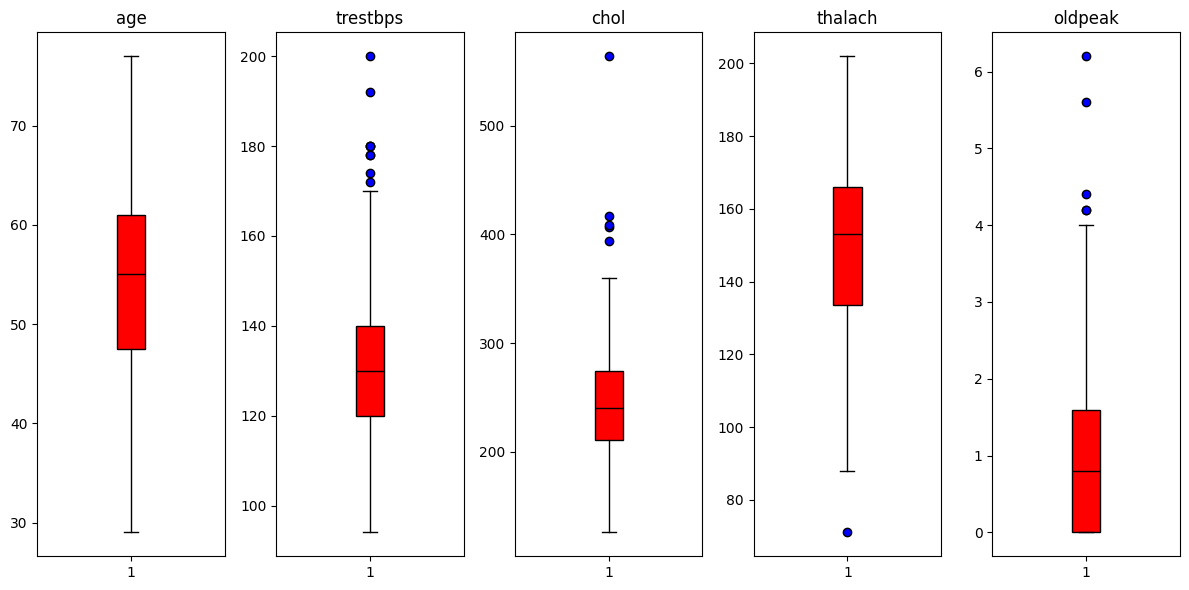

In [11]:
col = []
for index in df.columns:
    unique_number = df[index].nunique()
    if unique_number > 6:
        col.append(index)
fig , ax = plt.subplots(figsize=(12,6),ncols=len(col))
for i ,column in enumerate(col):
    ax[i].boxplot(df[column],patch_artist=True,boxprops={"facecolor":"red"},medianprops={"color":"black"},flierprops={"markerfacecolor":"blue"})
    ax[i].set_title(column)
plt.tight_layout()

In [257]:
dict_missing = {}
for col in df[numerical]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3-q1
    dict_missing[col] = df[(df[col]> q3 + (iqr * 1.5)) | (df[col] < q1 - (iqr * 1.5))]
for key,value in dict_missing.items():
    print(f"{key}->{len(value)}")


age->0
trestbps->9
chol->5
thalach->1
oldpeak->5


## سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

---

In [12]:
outlier_table = pd.DataFrame(outlier_info.items(), columns=["Feature", "No of Outliers"])
print(outlier_table)

    Feature  No of Outliers
0       age               0
1  trestbps               9
2      chol               5
3   thalach               1
4   oldpeak               5


## سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

۱.حذف داده پرت

۲.لگاریتم یا جذر گرفتن از اون ستون

۳.جایگزینی با سقف داده ها یعنی q3 + iqr *1.5

4.جایگزینی با میانگین یا میانه انگار داده گمشده است


---

multi dimentional 
one directional (normal distribution...)

quarts (putting third quantile or first quantile instead)



1. univariate (capping/winsorizing): har sotun ro barresi mikone va outlier IQR ro be Q3 va Q1 mahdood mikone. (relationship dar nazar nemigire)

2. univariate (removing record): recordaii ke value kharej az IQR darano delete mikone. (baraye vaghti ke motmaenim outlier khataye sabte na variance tabii).

    *age 9 recordo hazf konim (3%), riske kaheshe ghodrate amari modelo dare*
    
3. multivariate (combined IQR): chand sotun hamzaman barresi mikone. recordi outlier mahsoob mishe ke tooye bish az 1 sotun hamzaman meghdare outlier dashe bashe. (olgoo haye gheire tabii combination ro shenasaii mikone ke univariate nemikone).

## سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

---

In [13]:

for feature in col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[feature] = np.clip(df[feature], lower_bound, upper_bound)

outlier_info = {}

for feature in col:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    outlier_info[feature] = len(outliers)

print("Outliers after capping:")
print(outlier_info)

Outliers after capping:
{'age': 0, 'trestbps': 0, 'chol': 0, 'thalach': 0, 'oldpeak': 0}


# بخش سوم

# Data Construction

---

در این بخش باید ویژگی‌های جدید ایجاد شوند.

---

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [260]:
age_categorical = []
for index in df["age"]:
    if index < 18:
        index = "young"
        age_categorical.append(index)
    elif 40 > index:
        index = "middle age"
        age_categorical.append(index)
    else:
        index = "senior"
        age_categorical.append(index)
df.insert(1,"age_group",age_categorical)
df

,age,age_group,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,senior,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,middle age,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,senior,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,senior,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,senior,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,senior,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,senior,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,senior,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,senior,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [261]:
def chol_to_level(chol):
    if chol < 200:
        return "low"
    elif chol < 240:
        return "Normal"  
    else:
        return "High"

df["chol_level"] = df["chol"].apply(chol_to_level)
df[["chol", "chol_level"]].head(10)

chol chol_level
0  233.0     Normal
1  250.0       High
2  204.0     Normal
3  236.0     Normal
4  354.0       High
5  192.0        low
6  294.0       High
7  263.0       High
8  199.0        low
9  168.0        low

## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [16]:
def bp_to_level(bp):
    if bp < 120:
        return "Normal"
    elif bp < 140:
        return "Elevated"
    else:
        return "High"

df["bp_level"] = df["trestbps"].apply(bp_to_level)
df[["trestbps", "bp_level"]].head(30)

trestbps  bp_level
0        145      High
1        130  Elevated
2        130  Elevated
3        120  Elevated
4        120  Elevated
5        140      High
6        140      High
7        120  Elevated
8        170      High
9        150      High
10       140      High
11       130  Elevated
12       130  Elevated
13       110    Normal
14       150      High
15       120  Elevated
16       120  Elevated
17       150      High
18       150      High
19       140      High
20       135  Elevated
21       130  Elevated
22       140      High
23       150      High
24       140      High
25       160      High
26       150      High
27       110    Normal
28       140      High
29       130  Elevated

## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

In [17]:
df["hr_age_ratio"] = df["thalach"] / df["age"]
df["risk_factor_count"] = (
    (df["chol_level"] == "High").astype(int) +
    (df["bp_level"] == "High").astype(int) +
    (df["fbs"] == 1).astype(int) +
    (df["exang"] == 1).astype(int)
)

df[["hr_age_ratio", "risk_factor_count"]].head(10)

,hr_age_ratio,risk_factor_count
0,2.380952,2
1,5.054054,1
2,4.195122,0
3,3.178571,0
4,2.859649,2
5,2.596491,1
6,2.732143,2
7,3.931818,1
8,3.115385,2
9,3.052632,1


zaraban ghalbe normal ro barresi mikonim ke bebinim bar asase senesh zaraban ghalbe tabii dare ya na.
vizheghi dovom baraye model haye khati ke taamol beine vizhegi haro be khoobi nemibinan be kar miad.

## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

| **New Feature** | **Business Rationale** | **Type** |
| -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------- |
| **age_group** | Simplifies clinical interpretation and group-based analysis. Physicians typically make decisions based on age groups rather than exact age. | Categorical (derived from a numerical feature) |
| **chol_level** | Maps raw cholesterol values to standard NIH/AHA cholesterol categories, making the feature directly interpretable by clinicians. | Categorical (derived from a numerical feature) |
| **bp_level** | Applies the same concept to blood pressure, enabling quick identification of patients in clinically high-risk categories. | Categorical (derived from a numerical feature) |
| **hr_age_ratio** | Represents relative cardiovascular capacity by combining maximum heart rate and age into a meaningful physiological indicator. | Derived numerical feature |
| **multi_risk_score** | Aggregates multiple risk factors into a single score, which can improve the performance and interpretability of linear models. | Numerical (count/score) |


# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

In [263]:
df_lab = pd.read_csv("lab_results.csv")


## سوال 21

یک DataFrame آزمایشی بسازید.

---

In [264]:
df_lab = df_lab.drop(columns=["Pregnancies","BloodPressure","Age","DiabetesPedigreeFunction"])
df_lab_sample = df_lab.sample(n=303,random_state= 42)

## سوال 22

یک کلید مشترک تعریف کنید.

---

In [265]:
df_with_id = df.reset_index(drop=True).copy()
df_with_id["patient_id"] = np.arange(1, len(df_with_id) + 1)

common_key = "patient_id"
print(" common key:", common_key)
print("unique?",
      df_with_id[common_key].is_unique, lab_results[common_key].is_unique)

lab_results


,Glucose,SkinThickness,Insulin,BMI,Outcome,index
0,98,33,190,34.0,0,0
1,112,32,0,35.7,0,1
2,108,0,0,30.8,0,2
3,107,0,0,24.6,0,3
4,136,0,0,29.9,0,4
...,...,...,...,...,...,...
298,100,0,0,30.0,1,298
299,126,38,75,25.9,0,299
300,111,39,0,30.1,0,300
301,144,26,285,32.0,1,301


## سوال 23

Merge را انجام دهید.

---

In [20]:
merged_df = pd.merge(df_with_id, lab_results, on="patient_id", how="left")
merged_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,...,thal,target,age_group,chol_level,bp_level,hr_age_ratio,risk_factor_count,patient_id,glucose_level,creatinine
0,63,1,3,145,233.0,1,0,150.0,0,2.3,...,1,1,old,Normal,High,2.380952,2,1,107.5,1.12
1,37,1,2,130,250.0,0,1,187.0,0,3.5,...,2,1,Young,High,Elevated,5.054054,1,2,97.9,1.00
2,41,0,1,130,204.0,0,0,172.0,0,1.4,...,2,1,Middle Age,Normal,Elevated,4.195122,0,3,109.7,1.02
3,56,1,1,120,236.0,0,1,178.0,0,0.8,...,2,1,old,Normal,Elevated,3.178571,0,4,122.8,1.26
4,57,0,0,120,354.0,0,1,163.0,1,0.6,...,2,1,old,High,Elevated,2.859649,2,5,96.5,0.88


## سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer

---

inner: only records with matching keys in both tables. used when missing data is not acceptable and only matching records are needed.

left: all records from the left (primary) table. used When the primary table must be preserved completely, even if some records have no match.

right: all records from the right (secondary) table. used When the secondary table is the main source of data and must be preserved completely.

outer: all records from both tables. When no records should be lost, regardless of whether a match exists in the other table.


In [21]:
# inner_merge = pd.merge(df_with_id, lab_results, on="patient_id", how="inner")
# outer_merge = pd.merge(df_with_id, lab_results, on="patient_id", how="outer")
# print(inner_merge.shape, outer_merge.shape)

## سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.

---

left merge

chon be hameye dataye bimara niaz darim chon teedade recordamoon kaman. lab_results naghshe takmili dare, manteghi nist bekhatere naboodane natike azmayesh record asli ro pak konim (target mootabar). 

# بخش پنجم

# Data Formatting

---

## سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید.

---

In [268]:
df.info()

age                    int64
sex                    int64
cp                     int64
trestbps               int64
chol                 float64
fbs                    int64
restecg                int64
thalach              float64
exang                  int64
oldpeak              float64
slope                  int64
ca                     int64
thal                   int64
target                 int64
age_group             object
chol_level            object
bp_level              object
hr_age_ratio         float64
risk_factor_count      int64
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                303 non-null    int64  
 1   sex                303 non-null    int64  
 2   cp                 303 non-null    int64  
 3   trestbps           303 non-null    int64  
 4   chol               303 non-null    fl

## سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.

---

In [23]:
categorical_candidates = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
for col in categorical_candidates:
    values = sorted(df[col].astype(int).unique().tolist())
    print(col, "-> no. of unique values:", df[col].nunique(), "| values:", values)

sex -> no. of unique values: 2 | values: [0, 1]
cp -> no. of unique values: 4 | values: [0, 1, 2, 3]
fbs -> no. of unique values: 2 | values: [0, 1]
restecg -> no. of unique values: 3 | values: [0, 1, 2]
exang -> no. of unique values: 2 | values: [0, 1]
slope -> no. of unique values: 3 | values: [0, 1, 2]
ca -> no. of unique values: 5 | values: [0, 1, 2, 3, 4]
thal -> no. of unique values: 4 | values: [0, 1, 2, 3]
target -> no. of unique values: 2 | values: [0, 1]


## سوال 28

Datatype مناسب را اعمال کنید.

---

In [270]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            283 non-null    int64  
 1   age_group      283 non-null    str    
 2   sex            283 non-null    int64  
 3   cp             283 non-null    int64  
 4   trestbps       283 non-null    int64  
 5   trestbps risk  283 non-null    str    
 6   chol           283 non-null    int64  
 7   chol risk      283 non-null    str    
 8   fbs            283 non-null    int64  
 9   restecg        283 non-null    int64  
 10  thalach        283 non-null    int64  
 11  exang          283 non-null    int64  
 12  oldpeak        283 non-null    float64
 13  slope          283 non-null    int64  
 14  ca             283 non-null    int64  
 15  thal           283 non-null    int64  
 16  target         283 non-null    int64  
 17  index          283 non-null    int64  
 18  Glucose        283 no

In [271]:
for col in df[categorical]:
    df[col] = df[col].astype("category")

## سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.

---

In [272]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 283 entries, 0 to 282
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   age            283 non-null    int64   
 1   age_group      283 non-null    str     
 2   sex            283 non-null    int64   
 3   cp             283 non-null    category
 4   trestbps       283 non-null    int64   
 5   trestbps risk  283 non-null    str     
 6   chol           283 non-null    int64   
 7   chol risk      283 non-null    str     
 8   fbs            283 non-null    int64   
 9   restecg        283 non-null    category
 10  thalach        283 non-null    int64   
 11  exang          283 non-null    int64   
 12  oldpeak        283 non-null    float64 
 13  slope          283 non-null    category
 14  ca             283 non-null    category
 15  thal           283 non-null    category
 16  target         283 non-null    int64   
 17  index          283 non-null    int64   
 18  G

## سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE
```

---

In [273]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.title()
df
    

/tmp/ipykernel_4860/1387291106.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,...,slope,ca,thal,target,index,Glucose,SkinThickness,Insulin,BMI,Outcome
0,63,Senior,1,3,145,Elavated,233,High,1,0,...,0,0,1,1,0,98,33,190,34.0,0
1,37,Middle Age,1,2,130,Elavated,250,High,0,1,...,0,0,2,1,1,112,32,0,35.7,0
2,41,Senior,0,1,130,Elavated,204,High,0,0,...,2,0,2,1,2,108,0,0,30.8,0
3,56,Senior,1,1,120,Elavated,236,High,0,1,...,2,0,2,1,3,107,0,0,24.6,0
4,57,Senior,0,0,120,Elavated,354,High,0,1,...,2,0,2,1,4,136,0,0,29.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,241,High,0,1,...,1,0,3,0,298,100,0,0,30.0,1
279,45,Senior,1,3,110,Normal,264,High,0,1,...,1,0,3,0,299,126,38,75,25.9,0
280,68,Senior,1,0,144,Elavated,193,Normal,1,1,...,1,2,3,0,300,111,39,0,30.1,0
281,57,Senior,1,0,130,Elavated,131,Normal,0,1,...,1,1,3,0,301,144,26,285,32.0,1


# بخش ششم

# Data Reduction

---

## سوال 31

ویژگی‌های دارای واریانس بسیار کم را شناسایی کنید.

---

In [274]:
df[numerical].var().sort_values()

oldpeak              1.053498
BMI                 71.647476
age                 83.323785
trestbps           236.784227
SkinThickness      286.597599
thalach            514.909831
Glucose            971.269027
chol              1993.996491
index             7634.703656
Insulin          12871.550234
dtype: float64

## سوال 32

ویژگی‌های بسیار همبسته را شناسایی کنید.

---

In [275]:
lst = df.drop(columns="index").select_dtypes(exclude="object").columns
corr_matrix = df[lst].corr().abs()
mask = corr_matrix == 1
corr_matrix = corr_matrix[~mask]
for i in range(len(corr_matrix)):
    for j in range(i+1):
        corr_matrix.iloc[i,j] = np.nan
corr_matrix.unstack().dropna().sort_values(ascending=False)

slope          oldpeak          0.525142
Outcome        Glucose          0.482809
Insulin        SkinThickness    0.469847
target         oldpeak          0.434108
               exang            0.431599
                                  ...   
Glucose        ca               0.002525
exang          trestbps         0.001726
SkinThickness  fbs              0.001499
               sex              0.000996
Insulin        trestbps         0.000396
Length: 171, dtype: float64

## سوال 33

Heatmap جدید رسم کنید.

---

[Text(0, 0, 'age'),
 Text(0, 1, 'sex'),
 Text(0, 2, 'cp'),
 Text(0, 3, 'trestbps'),
 Text(0, 4, 'chol'),
 Text(0, 5, 'fbs'),
 Text(0, 6, 'restecg'),
 Text(0, 7, 'thalach'),
 Text(0, 8, 'exang'),
 Text(0, 9, 'oldpeak'),
 Text(0, 10, 'slope'),
 Text(0, 11, 'ca'),
 Text(0, 12, 'thal'),
 Text(0, 13, 'target'),
 Text(0, 14, 'Glucose'),
 Text(0, 15, 'SkinThickness'),
 Text(0, 16, 'Insulin'),
 Text(0, 17, 'BMI'),
 Text(0, 18, 'Outcome')]

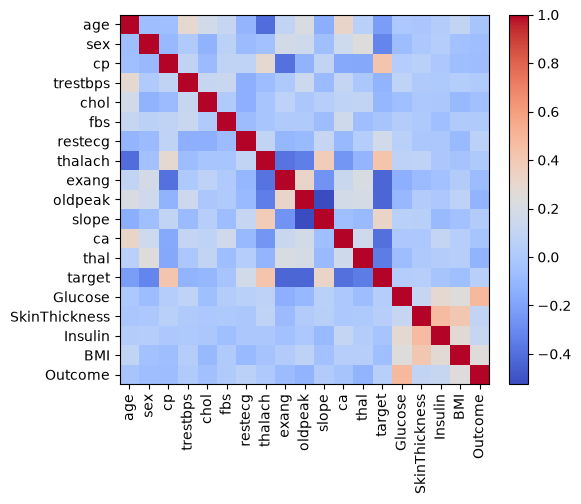

In [276]:
corr_matrix =df[lst].corr()
fig ,ax = plt.subplots()
img = ax.imshow(corr_matrix,cmap="coolwarm")
cbar = fig.colorbar(img,ax=ax,fraction = 0.05 , pad = 0.04)
ax.set_xticks(np.arange(len(df[lst].columns)))
ax.set_yticks(np.arange(len(df[lst].columns)))
ax.set_xticklabels(df[lst].columns,rotation = 90)
ax.set_yticklabels(df[lst].columns)

## سوال 34

اگر دو ویژگی همبستگی بالای 0.85 دارند:

کدام را حذف می‌کنید؟

چرا؟

---

agar hambastegi do vizhegi az 0.85 balatar bashad yaani etelaate besiar moshabehi erae midan va negah dashtan har do vizhegi baeese redundancy dade ha va kaheshe karaii baazi az model haye ML mishe.
vizhegii ke ertebate kamtari ba target dare remove mishe. age hardo ertebate yeksani ba target dashte bashan, vizhegii ke as nazare business understanding ahamiate kamtari dare delete mishe. 
agar ham missing value tooye yeki az sotuna bishtar bashe oon delete mishe. 

## سوال 35

یک نسخه کاهش‌یافته از دیتاست ایجاد کنید.

نام:

```python
reduced_df
```

---

In [277]:
df.select_dtypes(exclude=object).corr()["target"].sort_values()
df

,age,age_group,sex,cp,trestbps,trestbps risk,chol,chol risk,fbs,restecg,...,slope,ca,thal,target,index,Glucose,SkinThickness,Insulin,BMI,Outcome
0,63,Senior,1,3,145,Elavated,233,High,1,0,...,0,0,1,1,0,98,33,190,34.0,0
1,37,Middle Age,1,2,130,Elavated,250,High,0,1,...,0,0,2,1,1,112,32,0,35.7,0
2,41,Senior,0,1,130,Elavated,204,High,0,0,...,2,0,2,1,2,108,0,0,30.8,0
3,56,Senior,1,1,120,Elavated,236,High,0,1,...,2,0,2,1,3,107,0,0,24.6,0
4,57,Senior,0,0,120,Elavated,354,High,0,1,...,2,0,2,1,4,136,0,0,29.9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,241,High,0,1,...,1,0,3,0,298,100,0,0,30.0,1
279,45,Senior,1,3,110,Normal,264,High,0,1,...,1,0,3,0,299,126,38,75,25.9,0
280,68,Senior,1,0,144,Elavated,193,Normal,1,1,...,1,2,3,0,300,111,39,0,30.1,0
281,57,Senior,1,0,130,Elavated,131,Normal,0,1,...,1,1,3,0,301,144,26,285,32.0,1


In [278]:
df = df.drop(columns=["restecg","fbs","chol","chol risk","BMI","Insulin","Glucose","SkinThickness","Outcome","index"])
df

,age,age_group,sex,cp,trestbps,trestbps risk,thalach,exang,oldpeak,slope,ca,thal,target
0,63,Senior,1,3,145,Elavated,150,0,2.3,0,0,1,1
1,37,Middle Age,1,2,130,Elavated,187,0,3.5,0,0,2,1
2,41,Senior,0,1,130,Elavated,172,0,1.4,2,0,2,1
3,56,Senior,1,1,120,Elavated,178,0,0.8,2,0,2,1
4,57,Senior,0,0,120,Elavated,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,57,Senior,0,0,140,Elavated,123,1,0.2,1,0,3,0
279,45,Senior,1,3,110,Normal,132,0,1.2,1,0,3,0
280,68,Senior,1,0,144,Elavated,141,0,3.4,1,2,3,0
281,57,Senior,1,0,130,Elavated,115,1,1.2,1,1,3,0


# بخش هفتم

# Data Transformation

---

# Normalization & Scaling

---

## سوال 36

بررسی کنید آیا ویژگی‌های عددی مقیاس‌های متفاوت دارند یا خیر.

---

In [44]:
print(df_changed.select_dtypes(exclude="category").describe().T[["min","max","std"]])

                          min         max        std
age                 29.000000   77.000000   9.082101
trestbps            94.000000  170.000000  16.582241
chol               126.000000  369.750000  47.552910
thalach             84.750000  202.000000  22.762004
oldpeak              0.000000    4.000000   1.110127
hr_age_ratio         1.264925    6.965517   0.831393
risk_factor_count    0.000000    4.000000   0.977318


bale. Tooye algorithm haii mesle KNN, dade haii ba scaling bishtar az dade haii ba scaing kamtar bishtar asar mizaran.

## سوال 37

برای تمام ویژگی‌های عددی:

Min-Max Scaling را با NumPy پیاده‌سازی کنید.

فرمول:

```python
(x-min)/(max-min)
```

---

In [279]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)
for col in df[numerical]:
    x_max = df[col].max()
    x_min = df[col].min()
    min_max = (df[col] - x_min) / (x_max - x_min)

## سوال 38

برای تمام ویژگی‌های عددی:

Standardization را با NumPy پیاده‌سازی کنید.

---

In [280]:
numerical = []
categorical = []
boolian = []
for index , col in enumerate(df.columns):
    number_unique = df[col].nunique()
    if number_unique == 2:
        boolian.append(col)
    elif 6 > number_unique > 2 or df[col].dtype == "object":
        categorical.append(col)
    else:
        numerical.append(col)
for col in df[numerical]:
    x_mean = df[col].mean()
    x_std = df[col].std()
    z_score = (df[col] - x_mean) / x_std
    

## سوال 39

قبل و بعد از Scaling:

Histogram رسم کنید.

---

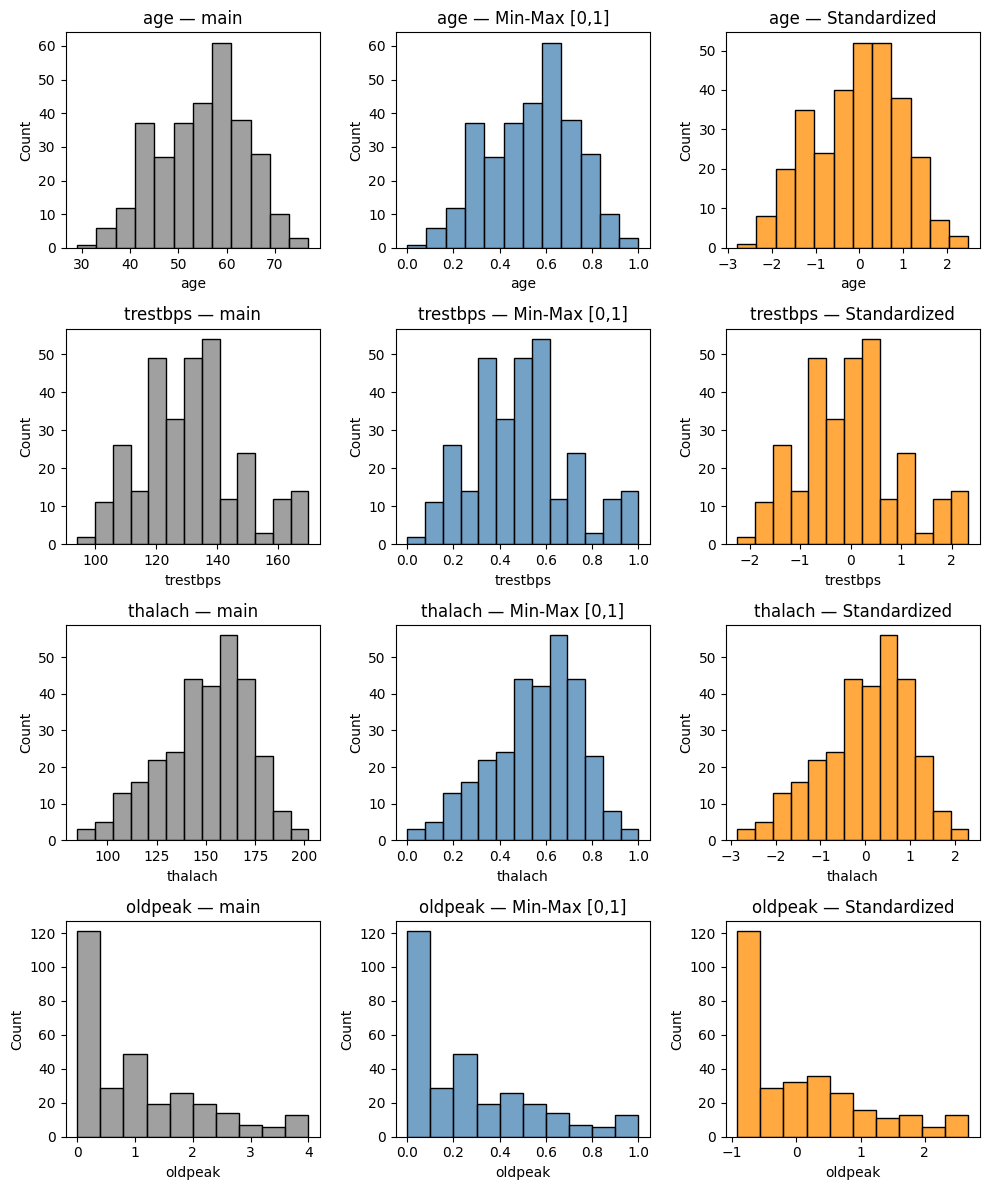

In [57]:
fig, axes = plt.subplots(len(numeric_cols), 3, figsize=(10, 3*len(numeric_cols)))

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], ax=axes[i,0], color="gray")
    axes[i,0].set_title(f"{col} — main")

    sns.histplot(df_minmax[col], ax=axes[i,1], color="steelblue")
    axes[i,1].set_title(f"{col} — Min-Max [0,1]")

    sns.histplot(df_standard[col], ax=axes[i,2], color="darkorange")
    axes[i,2].set_title(f"{col} — Standardized")

plt.tight_layout()
plt.show()

## سوال 40

مقایسه کنید:

* MinMax
* Standardization

برای این پروژه کدام مناسب‌تر است؟

---

In [281]:

for col in df[numerical]:
    x_mean = df[col].mean()
    x_std = df[col].std()
    z_score = (df[col] - x_mean) / x_std
    df[col] = z_score
df

,age,age_group,sex,cp,trestbps,trestbps risk,thalach,exang,oldpeak,slope,ca,thal,target
0,0.980538,Senior,1,3,0.982376,Elavated,0.001713,0,1.313383,0,0,1,1
1,-1.867783,Middle Age,1,2,0.007578,Elavated,1.632270,0,2.482517,0,0,2,1
2,-1.429580,Senior,0,1,0.007578,Elavated,0.971234,0,0.436532,2,0,2,1
3,0.213682,Senior,1,1,-0.642288,Elavated,1.235648,0,-0.148035,2,0,2,1
4,0.323233,Senior,0,0,-0.642288,Elavated,0.574612,1,-0.342891,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,0.323233,Senior,0,0,0.657444,Elavated,-1.188153,1,-0.732602,1,0,3,0
279,-0.991377,Senior,1,3,-1.292153,Normal,-0.791531,0,0.241676,1,0,3,0
280,1.528292,Senior,1,0,0.917390,Elavated,-0.394909,0,2.385089,1,2,3,0
281,0.323233,Senior,1,0,0.007578,Elavated,-1.540706,1,0.241676,1,1,3,0


# بخش هشتم

# Dataset Validation

---

## سوال 41

شکل نهایی دیتاست را گزارش کنید.

---

In [31]:
final_df = df_standard.copy()  # یا هر نسخه نهایی که انتخاب کرده‌اید
print("شکل نهایی دیتاست:", final_df.shape)
print("ستون‌ها:", list(final_df.columns))

NameError: name 'df_standard' is not defined

## سوال 42

آیا Null باقی مانده است؟

---

In [ ]:
remaining_nulls = final_df.isnull().sum().sum()
print("تعداد Null باقیمانده:", remaining_nulls)
assert remaining_nulls == 0, "هنوز مقادیر Null وجود دارد!"

تعداد Null باقیمانده: 0


## سوال 43

آیا Duplicate باقی مانده است؟

---

In [ ]:
# remaining_duplicates = final_df.duplicated().sum()
# print("تعداد رکورد تکراری باقیمانده:", remaining_duplicates)
# assert remaining_duplicates == 0, "هنوز رکورد تکراری وجود دارد!"

## سوال 44

آیا Outlier ها مدیریت شده‌اند؟

---

In [ ]:
for col in numeric_cols_final:
    Q1 = final_df[col].quantile(0.25)
    Q3 = final_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    remaining_outliers = final_df[(final_df[col] < lower_bound) | (final_df[col] > upper_bound)]
    print(f"{col}: {len(remaining_outliers)} outlier باقیمانده")

age: 0 outlier باقیمانده
sex: 0 outlier باقیمانده
cp: 0 outlier باقیمانده
trestbps: 9 outlier باقیمانده
thalach: 1 outlier باقیمانده
slope: 0 outlier باقیمانده
exang: 0 outlier باقیمانده
oldpeak: 5 outlier باقیمانده
ca: 25 outlier باقیمانده
thal: 2 outlier باقیمانده


## سوال 45

آیا تمامی ویژگی‌ها فرمت مناسبی دارند؟

---

In [ ]:
print(final_df.dtypes)
print("\nستون‌های غیرعددی (که باید encode شوند قبل از مدل‌سازی):")
print(final_df.select_dtypes(exclude=[np.number]).columns.tolist())

age         float64
sex         float64
cp          float64
trestbps    float64
thalach     float64
slope       float64
exang       float64
oldpeak     float64
ca          float64
thal        float64
target        int64
dtype: object

ستون‌های غیرعددی (که باید encode شوند قبل از مدل‌سازی):
[]


## سوال 46

آیا داده برای KNN مناسب است؟

توضیح دهید.

---

## سوال 47

آیا داده برای Logistic Regression مناسب است؟

توضیح دهید.

---

## سوال 48

آیا داده برای Decision Tree مناسب است؟

توضیح دهید.

---

## سوال 49

دیتاست نهایی را ذخیره کنید:

```python
heart_prepared.csv
```

---

## سوال 50

یک گزارش مدیریتی تهیه کنید.

به سوالات زیر پاسخ دهید:

1. چه تغییراتی روی داده انجام شد؟
2. چه ویژگی‌هایی حذف شدند؟
3. چه ویژگی‌هایی ساخته شدند؟
4. چه مشکلاتی برطرف شد؟
5. آیا داده برای Modeling آماده است؟

---

# تحویل پروژه

فایل‌های زیر باید ارسال شوند:

```python
task002_data_preparation.ipynb
heart_prepared.csv
```

---

# هدف آموزشی این تسک

پس از پایان این تمرین دانشجو باید بتواند:

✅ Data Selection انجام دهد

✅ Data Cleaning انجام دهد

✅ Feature Construction انجام دهد

✅ Data Integration انجام دهد

✅ Data Formatting انجام دهد

✅ Data Reduction انجام دهد

✅ Scaling و Normalization انجام دهد

✅ یک دیتاست خام را به یک دیتاست آماده مدل‌سازی تبدیل کند

این دقیقاً خروجی مورد انتظار مرحله Data Preparation در فرآیند CRISP-DM است.